# 🚗 Car Price Prediction


**Goal:** Build a complete regression model that predicts the selling price of a used car from its features.

### Project workflow
1. Import libraries
2. Load / create dataset
3. Understand the data
4. Clean the data
5. Exploratory Data Analysis (EDA)
6. Feature engineering
7. Prepare X and y
8. Train-test split
9. Preprocess numerical + categorical features
10. Train multiple regression models
11. Evaluate and compare models
12. Select the best model
13. Predict price for a new car
14. Save the trained model

**Target:** `Selling_Price`


## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


In [2]:
import pandas as pd

df = pd.read_csv("Car_Price_Prediction_Dataset.csv")
df.head()

,Brand,Year,Km_Driven,Fuel_Type,Transmission,Owner,Location,Engine_CC,Mileage,Seats,Insurance,Selling_Price
0,Mahindra,2012,148273,Electric,Manual,Third,Hyderabad,1000,11.4,5,Yes,7.71
1,Toyota,2019,34426,Diesel,Manual,First,Mumbai,2500,25.9,6,Yes,17.70
2,Ford,2023,22778,Petrol,Manual,First,Hyderabad,1400,11.4,4,No,14.09
3,Tata,2022,47229,Diesel,Manual,Second,Pune,2500,22.7,5,Yes,17.70
4,Mahindra,2023,91652,Petrol,Manual,First,Mumbai,2200,26.6,5,Yes,16.44


## 3. Understand the Dataset

In [3]:
print('Rows and columns:', df.shape)
display(df.head())


Rows and columns: (1000, 12)


,Brand,Year,Km_Driven,Fuel_Type,Transmission,Owner,Location,Engine_CC,Mileage,Seats,Insurance,Selling_Price
0,Mahindra,2012,148273,Electric,Manual,Third,Hyderabad,1000,11.4,5,Yes,7.71
1,Toyota,2019,34426,Diesel,Manual,First,Mumbai,2500,25.9,6,Yes,17.70
2,Ford,2023,22778,Petrol,Manual,First,Hyderabad,1400,11.4,4,No,14.09
3,Tata,2022,47229,Diesel,Manual,Second,Pune,2500,22.7,5,Yes,17.70
4,Mahindra,2023,91652,Petrol,Manual,First,Mumbai,2200,26.6,5,Yes,16.44


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          1000 non-null   str    
 1   Year           1000 non-null   int64  
 2   Km_Driven      1000 non-null   int64  
 3   Fuel_Type      1000 non-null   str    
 4   Transmission   1000 non-null   str    
 5   Owner          1000 non-null   str    
 6   Location       1000 non-null   str    
 7   Engine_CC      1000 non-null   int64  
 8   Mileage        1000 non-null   float64
 9   Seats          1000 non-null   int64  
 10  Insurance      1000 non-null   str    
 11  Selling_Price  1000 non-null   float64
dtypes: float64(2), int64(4), str(6)
memory usage: 93.9 KB


In [5]:
display(df.describe(include='all').T)
print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False))
print('\nDuplicate rows:', df.duplicated().sum())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,1000,10,Maruti,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1000.0,NaN,NaN,NaN,2018.504,4.080764,2012.0,2015.0,2019.0,2022.0,2025.0
Km_Driven,1000.0,NaN,NaN,NaN,93376.19,50912.537009,5163.0,47457.0,94476.5,138824.5,179668.0
Fuel_Type,1000,4,Petrol,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,1000,2,Manual,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,1000,3,First,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,1000,6,Mumbai,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_CC,1000.0,NaN,NaN,NaN,1604.6,509.35084,800.0,1200.0,1600.0,2000.0,2500.0
Mileage,1000.0,NaN,NaN,NaN,18.8211,5.125458,10.0,14.4,18.7,23.3,28.0
Seats,1000.0,NaN,NaN,NaN,5.416,0.935852,4.0,5.0,5.0,6.0,7.0



Missing values:


Brand            0
Year             0
Km_Driven        0
Fuel_Type        0
Transmission     0
Owner            0
Location         0
Engine_CC        0
Mileage          0
Seats            0
Insurance        0
Selling_Price    0
dtype: int64


Duplicate rows: 0


## 4. Data Cleaning

In [6]:
# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Normalize text columns
for col in ['Brand', 'Fuel_Type', 'Transmission', 'Owner', 'Location', 'Insurance']:
    df[col] = df[col].astype('string').str.strip()

print('Shape after removing duplicates:', df.shape)
display(df.isnull().sum())

# Note: remaining missing values are intentionally handled later inside the ML pipeline
# using SimpleImputer, which prevents data leakage.


Shape after removing duplicates: (1000, 12)


Brand            0
Year             0
Km_Driven        0
Fuel_Type        0
Transmission     0
Owner            0
Location         0
Engine_CC        0
Mileage          0
Seats            0
Insurance        0
Selling_Price    0
dtype: int64

## 5. Exploratory Data Analysis (EDA)

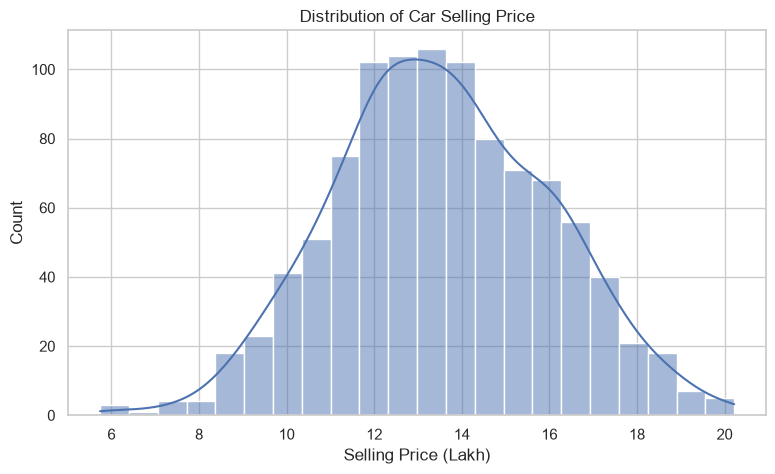

In [7]:
plt.figure(figsize=(9,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Car Selling Price')
plt.xlabel('Selling Price (Lakh)')
plt.show()


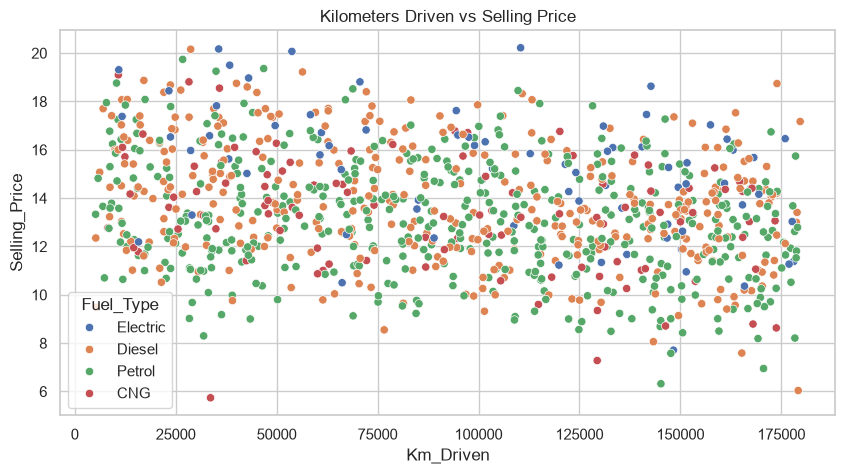

In [8]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Km_Driven', y='Selling_Price', hue='Fuel_Type')
plt.title('Kilometers Driven vs Selling Price')
plt.show()


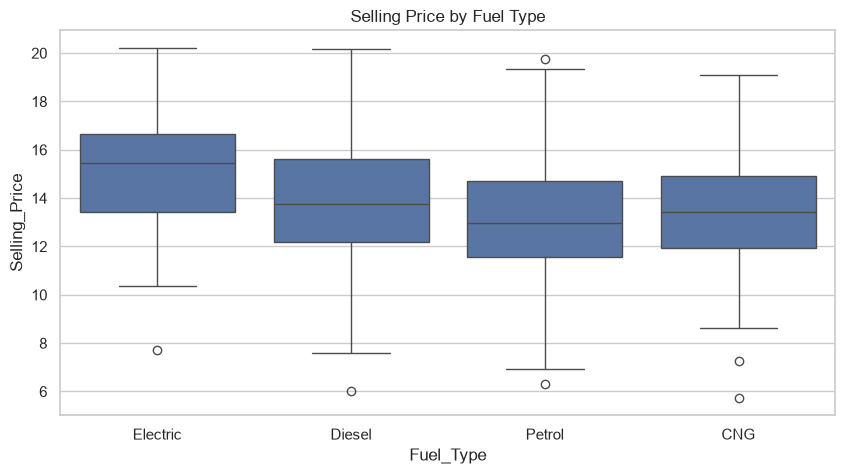

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price by Fuel Type')
plt.show()


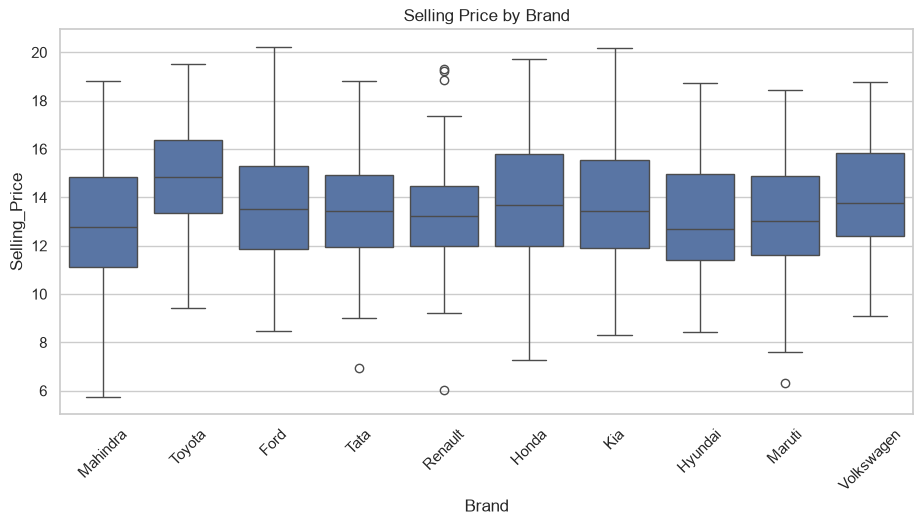

In [10]:
plt.figure(figsize=(11,5))
sns.boxplot(data=df, x='Brand', y='Selling_Price')
plt.xticks(rotation=45)
plt.title('Selling Price by Brand')
plt.show()


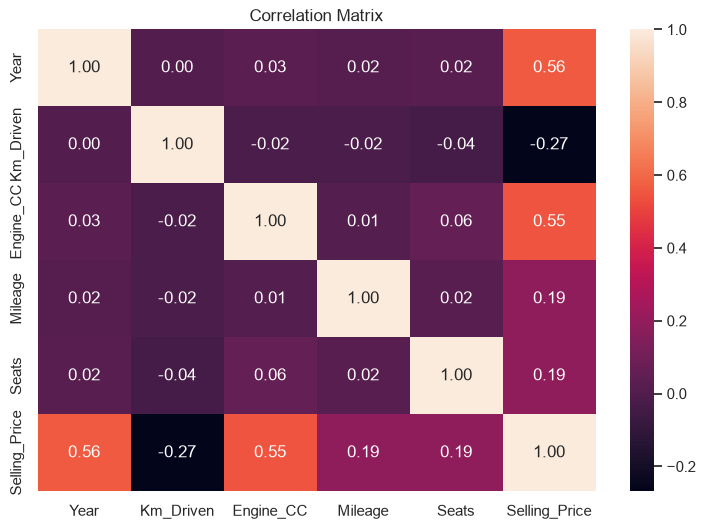

In [11]:
numeric_cols = ['Year', 'Km_Driven', 'Engine_CC', 'Mileage', 'Seats', 'Selling_Price']
plt.figure(figsize=(9,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


## 6. Feature Engineering

In [12]:
df['Car_Age'] = 2026 - df['Year']
df['Km_per_Year'] = df['Km_Driven'] / df['Car_Age'].replace(0, 1)

display(df[['Year', 'Car_Age', 'Km_Driven', 'Km_per_Year']].head())


,Year,Car_Age,Km_Driven,Km_per_Year
0,2012,14,148273,10590.928571
1,2019,7,34426,4918.000000
2,2023,3,22778,7592.666667
3,2022,4,47229,11807.250000
4,2023,3,91652,30550.666667


## 7. Define Features (X) and Target (y)

In [13]:
X = df.drop(columns='Selling_Price')
y = df['Selling_Price']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)


Feature shape: (1000, 13)
Target shape: (1000,)


## 8. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Testing rows :', X_test.shape[0])


Training rows: 800
Testing rows : 200


## 9. Preprocessing Pipeline

In [15]:
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print('Categorical features:', categorical_features)
print('Numerical features:', numerical_features)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


Categorical features: ['Brand', 'Fuel_Type', 'Transmission', 'Owner', 'Location', 'Insurance']
Numerical features: ['Year', 'Km_Driven', 'Engine_CC', 'Mileage', 'Seats', 'Car_Age', 'Km_per_Year']


## 10. Train Multiple Regression Models

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=200)
}

results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])
    trained_models[name] = pipe

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2 Score']).sort_values('R2 Score', ascending=False)
display(results_df)


,Model,MAE,RMSE,R2 Score
1,Ridge Regression,0.696701,0.857820,0.870052
0,Linear Regression,0.698112,0.858466,0.869856
3,Gradient Boosting,0.789673,1.011292,0.819395
2,Random Forest,0.934836,1.225315,0.734861


## 11. Understand the Evaluation Metrics

**MAE (Mean Absolute Error):** Average absolute prediction error. Lower is better.

**RMSE (Root Mean Squared Error):** Penalizes larger errors more strongly. Lower is better.

**R² Score:** Measures how much variation in the target is explained by the model. Higher is better; 1.0 is perfect.

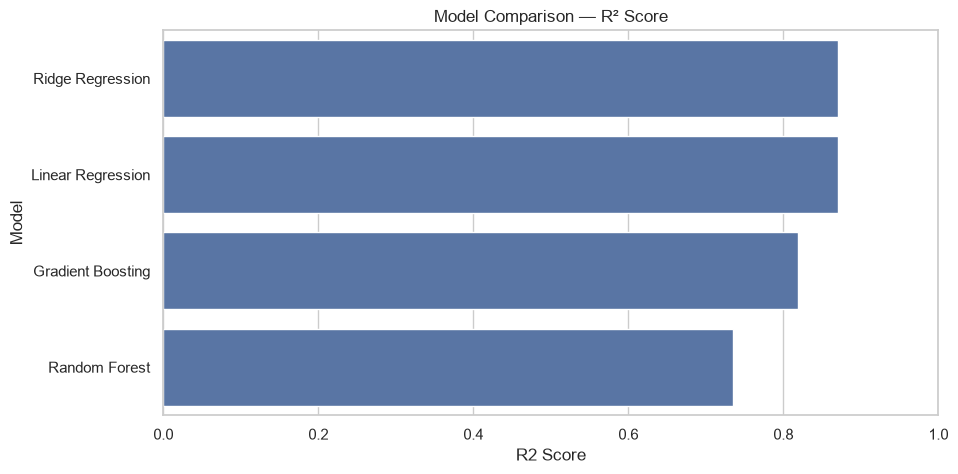

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='R2 Score', y='Model')
plt.xlim(min(0, results_df['R2 Score'].min() - 0.05), 1.0)
plt.title('Model Comparison — R² Score')
plt.show()


## 12. Select the Best Model

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print('Best model:', best_model_name)

test_predictions = best_model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': test_predictions})
display(comparison.head(10))


Best model: Ridge Regression


,Actual,Predicted
0,14.27,13.280477
1,10.96,10.892617
2,10.37,9.172146
3,12.35,13.602117
4,14.33,13.985776
5,16.00,14.680344
6,17.34,16.813571
7,14.39,15.125029
8,15.82,16.213876
9,14.22,13.285537


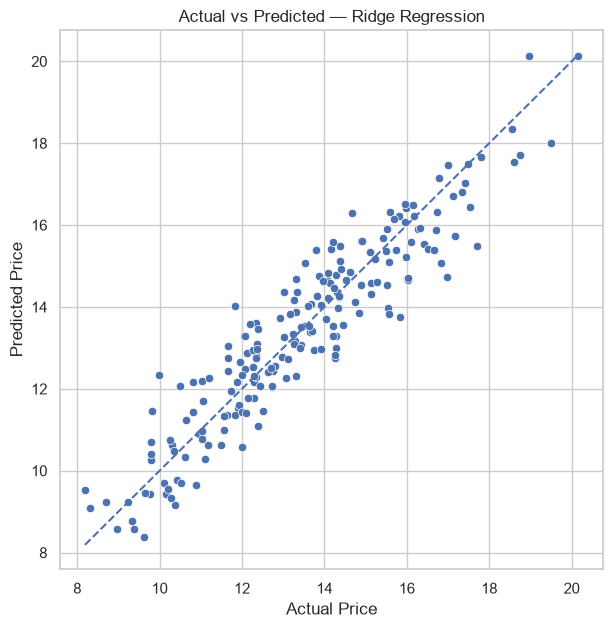

In [19]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=test_predictions)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted — {best_model_name}')
min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.show()


## 13. Predict the Price of a New Car

In [20]:
new_car = pd.DataFrame([{
    'Brand': 'Honda',
    'Year': 2023,
    'Km_Driven': 25000,
    'Fuel_Type': 'Petrol',
    'Transmission': 'Automatic',
    'Owner': 'First',
    'Location': 'Hyderabad',
    'Engine_CC': 1500,
    'Mileage': 18.5,
    'Seats': 5,
    'Insurance': 'Yes',
    'Car_Age': 3,
    'Km_per_Year': 25000 / 3
}])

predicted_price = best_model.predict(new_car)[0]
print(f'Predicted selling price: ₹{predicted_price:.2f} lakh')


Predicted selling price: ₹16.37 lakh


## 14. Try Your Own Car Prediction

In [21]:
def predict_car_price(brand, year, km_driven, fuel_type, transmission, owner,
                      location, engine_cc, mileage, seats, insurance):
    car_age = 2026 - year
    car = pd.DataFrame([{
        'Brand': brand, 'Year': year, 'Km_Driven': km_driven,
        'Fuel_Type': fuel_type, 'Transmission': transmission, 'Owner': owner,
        'Location': location, 'Engine_CC': engine_cc, 'Mileage': mileage,
        'Seats': seats, 'Insurance': insurance, 'Car_Age': car_age,
        'Km_per_Year': km_driven / max(car_age, 1)
    }])
    prediction = best_model.predict(car)[0]
    return prediction

# Change these values and run the cell again.
price = predict_car_price(
    brand='Toyota', year=2022, km_driven=30000,
    fuel_type='Petrol', transmission='Automatic', owner='First',
    location='Hyderabad', engine_cc=1800, mileage=18.0,
    seats=5, insurance='Yes'
)
print(f'Estimated price: ₹{price:.2f} lakh')


Estimated price: ₹17.17 lakh


## 15. Save the Trained Model

In [22]:
joblib.dump(best_model, 'car_price_prediction_model.pkl')
print('Model saved as car_price_prediction_model.pkl')

# To download from Google Colab:
try:
    from google.colab import files
    files.download('car_price_prediction_model.pkl')
except ModuleNotFoundError:
    print('Running in VS Code - model file is already saved in the project folder.')

# You can also download the dataset with:
try:
    files.download('car_price_dataset.csv')
except NameError:
    print('Dataset is already available in the project folder.')

Model saved as car_price_prediction_model.pkl
Running in VS Code - model file is already saved in the project folder.
Dataset is already available in the project folder.
